# Phase 2 — Feature Extraction

We describe each 30 s clip with two complementary feature families and summarise them into a fixed-length vector.

- **MFCC (20) + CMN** — spectral shape / timbre, with cepstral mean normalisation to suppress the recording channel.
- **Chroma (12)** — pitch-class content (the musically meaningful descriptor of a scale), resistant to the bandwidth confound.

Each coefficient is summarised over time by its **mean** and **standard deviation**, giving a **64-dimensional** vector per clip
(20 MFCC × 2 + 12 chroma × 2).

In [2]:
import numpy as np, librosa, librosa.display, matplotlib.pyplot as plt, pandas as pd
from pathlib import Path
from collections import Counter

# Anchor to project root: works whether run from repo root or notebooks/.
# Figures/features go to the SHARED root folders (same as the src/ scripts).
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW  = ROOT / 'data' / 'raw'
FEAT = ROOT / 'features'; FEAT.mkdir(exist_ok=True)
FIG  = ROOT / 'figures';  FIG.mkdir(exist_ok=True)
SR = 16000
N_FFT, HOP, N_MFCC = 2048, 512, 20

# pre-processing from Phase 1 (repeated so this notebook is self-contained)
def preprocess(path, sr=SR, pre_emph=0.97):
    y, _ = librosa.load(path, sr=sr, mono=True)
    y = y - np.mean(y)
    y = np.append(y[0], y[1:] - pre_emph * y[:-1])
    peak = np.max(np.abs(y))
    return y / peak if peak > 0 else y

## 2.1  Log-Mel spectrogram
The Mel scale allocates more resolution to low frequencies, matching human hearing and the region where the scale's pitch content lives.

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


log-Mel shape (mels, frames): (128, 938)


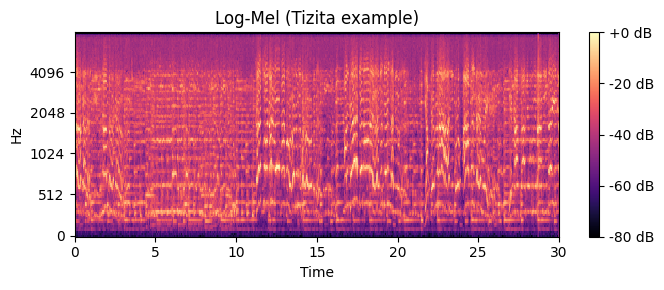

In [3]:
def log_mel(y, n_mels=128):
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=n_mels)
    return librosa.power_to_db(S, ref=np.max)

example = next((RAW/'tizita').glob('*.wav'))
M = log_mel(preprocess(example))
print('log-Mel shape (mels, frames):', M.shape)
plt.figure(figsize=(7,3))
librosa.display.specshow(M, sr=SR, hop_length=HOP, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB'); plt.title('Log-Mel (Tizita example)'); plt.tight_layout()
plt.savefig(FIG/'logmel_example.png', dpi=150); plt.show()

log-Mel shape (mels, frames): (128, 938)


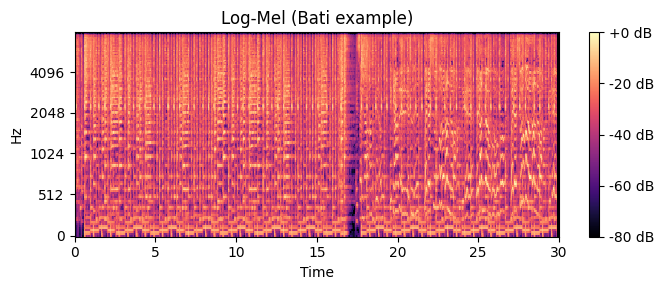

In [4]:
def log_mel(y, n_mels=128):
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=n_mels)
    return librosa.power_to_db(S, ref=np.max)

example = next((RAW/'bati').glob('*.wav'))
M = log_mel(preprocess(example))
print('log-Mel shape (mels, frames):', M.shape)
plt.figure(figsize=(7,3))
librosa.display.specshow(M, sr=SR, hop_length=HOP, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB'); plt.title('Log-Mel (Bati example)'); plt.tight_layout()
plt.savefig(FIG/'logmel_example.png', dpi=150); plt.show()

## 2.2  MFCC with cepstral mean normalisation (CMN)
MFCC pipeline: windowed signal → FFT → Mel filterbank → log → DCT, keeping the first 20 coefficients.
**CMN** subtracts each coefficient's mean over the clip, removing the constant channel signature (a confound countermeasure).

MFCC shape (coeffs, frames): (20, 938)


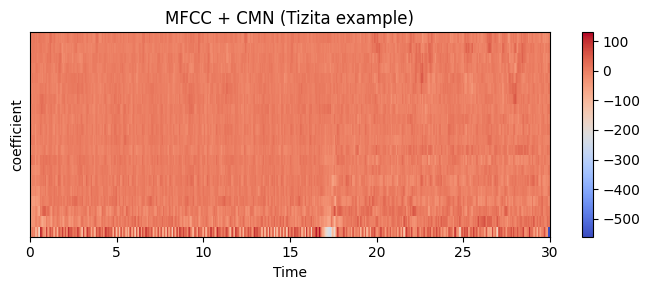

In [5]:
def mfcc_cmn(y):
    m = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP)
    return m - np.mean(m, axis=1, keepdims=True)   # CMN

m = mfcc_cmn(preprocess(example))
print('MFCC shape (coeffs, frames):', m.shape)
plt.figure(figsize=(7,3))
librosa.display.specshow(m, sr=SR, hop_length=HOP, x_axis='time')
plt.colorbar(); plt.title('MFCC + CMN (Tizita example)'); plt.ylabel('coefficient'); plt.tight_layout()
plt.savefig(FIG/'mfcc_example.png', dpi=150); plt.show()

## 2.3  Chroma (12 pitch classes)
Folds all spectral energy onto the 12 pitch classes (C, C#, …, B), collapsing octaves. Tizita and Bati emphasise different pitch classes.

chroma shape (12, frames): (12, 938)


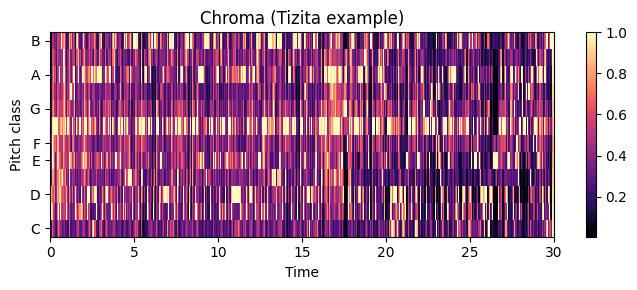

In [6]:
def chroma(y):
    return librosa.feature.chroma_stft(y=y, sr=SR, n_fft=N_FFT, hop_length=HOP)

c = chroma(preprocess(example))
print('chroma shape (12, frames):', c.shape)
plt.figure(figsize=(7,3))
librosa.display.specshow(c, sr=SR, hop_length=HOP, x_axis='time', y_axis='chroma')
plt.colorbar(); plt.title('Chroma (Tizita example)'); plt.tight_layout()
plt.savefig(FIG/'chroma_example.png', dpi=150); plt.show()

## 2.4  Build the feature matrix
For every clip: MFCC+CMN and chroma → mean and std over time → concatenate.

Column layout (64): `mfcc0_mean..mfcc19_mean, mfcc0_std..mfcc19_std, chroma0_mean..chroma11_mean, chroma0_std..chroma11_std`.

In [7]:
def features_for(y):
    m = mfcc_cmn(y); c = chroma(y)
    return np.concatenate([m.mean(1), m.std(1), c.mean(1), c.std(1)])

X, y_lab, names = [], [], []
for scale in ['bati', 'tizita']:
    for wav in sorted((RAW/scale).glob('*.wav')):
        X.append(features_for(preprocess(wav)))
        y_lab.append(scale); names.append(wav.name)
X = np.array(X); y_lab = np.array(y_lab)
print('feature matrix:', X.shape, '| labels:', dict(Counter(y_lab)))

feature matrix: (306, 64) | labels: {np.str_('bati'): 144, np.str_('tizita'): 162}


In [8]:
# column names + save
cols  = [f'mfcc{i}_mean' for i in range(20)] + [f'mfcc{i}_std' for i in range(20)]
cols += [f'chroma{i}_mean' for i in range(12)] + [f'chroma{i}_std' for i in range(12)]
np.save(FEAT/'X.npy', X)
np.save(FEAT/'y.npy', y_lab)
pd.DataFrame(X, columns=cols).assign(label=y_lab, file=names).to_csv(FEAT/'features.csv', index=False)
print('saved features/X.npy, features/y.npy, features/features.csv')


saved features/X.npy, features/y.npy, features/features.csv


In [9]:
import pandas as pd
df = pd.read_csv(FEAT / "features.csv")
df

,mfcc0_mean,mfcc1_mean,mfcc2_mean,mfcc3_mean,mfcc4_mean,mfcc5_mean,mfcc6_mean,mfcc7_mean,mfcc8_mean,mfcc9_mean,...,chroma4_std,chroma5_std,chroma6_std,chroma7_std,chroma8_std,chroma9_std,chroma10_std,chroma11_std,label,file
0,1.561667e-06,-7.808336e-07,0.000000e+00,-1.301389e-06,6.506946e-08,1.626737e-08,-1.301389e-07,-9.760419e-08,-6.506946e-08,1.301389e-07,...,0.252106,0.351081,0.261531,0.225155,0.315938,0.295078,0.339613,0.221444,bati,Bati1.wav
1,-2.407570e-06,-7.808336e-07,-6.506946e-07,6.506946e-07,3.578820e-07,1.301389e-07,-1.952084e-07,3.904168e-07,-2.602779e-07,1.626737e-07,...,0.203671,0.358788,0.188363,0.314676,0.314516,0.204166,0.265379,0.214342,bati,Bati10.wav
2,-7.808336e-07,2.602779e-07,1.301389e-07,-1.301389e-07,-3.578820e-07,6.506946e-08,-9.760419e-08,1.626737e-07,5.205557e-07,2.602779e-07,...,0.363628,0.192307,0.240153,0.302904,0.282492,0.343416,0.279651,0.372723,bati,Bati100.wav
3,-1.041111e-06,0.000000e+00,-2.602779e-07,-4.554862e-07,-1.952084e-07,6.506946e-08,-1.301389e-07,3.253473e-08,1.626737e-08,-1.301389e-07,...,0.283353,0.368585,0.247797,0.306468,0.288673,0.304791,0.326419,0.231681,bati,Bati101.wav
4,-6.246668e-06,-1.496598e-06,-3.904168e-07,6.506946e-07,1.301389e-07,3.904168e-07,-1.952084e-07,7.808336e-07,-1.464063e-07,-1.952084e-07,...,0.202473,0.230441,0.301847,0.333521,0.371855,0.266773,0.296791,0.257503,bati,Bati102.wav
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,1.561667e-06,-2.602779e-07,-5.205557e-07,-6.506946e-08,1.952084e-07,-6.506946e-07,5.896920e-07,1.301389e-07,9.272399e-07,1.626737e-07,...,0.302830,0.241624,0.270893,0.301143,0.257553,0.330769,0.208016,0.267981,tizita,Tizita95.wav
302,-2.082223e-06,2.602779e-07,0.000000e+00,1.952084e-07,-1.626737e-07,8.133683e-08,7.157641e-07,3.253473e-07,1.952084e-07,-3.904168e-07,...,0.248910,0.309794,0.203738,0.312006,0.216562,0.220829,0.300309,0.151262,tizita,Tizita96.wav
303,-2.082223e-06,-1.301389e-07,2.602779e-07,-2.602779e-07,-3.904168e-07,-5.856252e-07,-5.205557e-07,-1.952084e-07,-1.183451e-06,-3.253473e-08,...,0.293645,0.184037,0.311014,0.183604,0.217460,0.289371,0.182764,0.279076,tizita,Tizita97.wav
304,2.602778e-06,9.109725e-07,-6.506946e-07,-2.277431e-07,-1.122448e-06,-8.133683e-08,3.904168e-07,1.301389e-07,4.880210e-07,-2.114758e-07,...,0.197137,0.331581,0.222480,0.274391,0.316441,0.217088,0.318674,0.214055,tizita,Tizita98.wav


---
**Next:** Phase 3 — k-means clustering and PCA visualisation.